In [ ]:
import os
import json
import shutil
import cv2
import numpy as np

from typing import List

def process_landmark_annotations(
    json_path: str,
    output_dir: str,
    images_dir: str,
    normalize: bool = False
) -> None:
    """
    Process JSON facial landmark annotations and create organized .txt files for each image.

    Args:
        json_path (str): Path to the JSON file containing the landmark annotations.
        output_dir (str): Path to the output directory where 'images' and 'labels' folders will be created.
        images_dir (str): Path to the directory containing the original images.
        normalize (bool): If True, normalize landmark coordinates with respect to the image dimensions.

    Returns:
        None
    """
    # Define the ordered list of 72 landmarks
    landmarks_order = [
        f"face_contour_{i}" for i in range(1, 18)
    ] + [
        f"right_eyebrow_{i}" for i in range(18, 23)
    ] + [
        f"left_eyebrow_{i}" for i in range(23, 28)
    ] + [
        f"nose_bridge_{i}" for i in range(28, 32)
    ] + [
        f"nose_base_{i}" for i in range(32, 37)
    ] + [
        f"right_eye_{i}" for i in range(37, 43)
    ] + [
        f"left_eye_{i}" for i in range(43, 49)
    ] + [
        f"outer_lip_{i}" for i in range(49, 61)
    ] + [
        f"inner_lip_{i}" for i in range(61, 69)
    ] + [
        "under_lip_69", "upper_chin70", "left_chin_71", "right_chin_72"
    ]

    # Create output directories
    images_output_dir = os.path.join(output_dir, "images")
    labels_output_dir = os.path.join(output_dir, "labels")
    os.makedirs(images_output_dir, exist_ok=True)
    os.makedirs(labels_output_dir, exist_ok=True)

    # Load the JSON annotations
    with open(json_path, 'r') as f:
        annotations = json.load(f)

    for annotation in annotations:
        # Extract image information
        image_path = annotation["image"].split("?d=")[-1]  # Clean up image path
        image_name = os.path.basename(image_path)
        original_width = annotation["landmarks"][0]["original_width"]
        original_height = annotation["landmarks"][0]["original_height"]

        # Initialize landmarks with NaN for each image
        landmarks_data = {key: (np.nan, np.nan) for key in landmarks_order}

        # Fill in available landmark data
        for landmark in annotation["landmarks"]:
            label = landmark["keypointlabels"][0]
            x, y = landmark["x"], landmark["y"]

            # Step 1: Ensure desnormalization from 0-100 to absolute pixel
            if 0 <= x <= 100 and 0 <= y <= 100:
                # Rescale x and y from [0, 100] to [0, original_width] and [0, original_height]
                x = (x / 100) * original_width
                y = (y / 100) * original_height

            # Step 2: Normalize if requested
            if normalize:
                x /= original_width
                y /= original_height

            # Convert to integer if not normalized
            if not normalize:
                x = int(round(x))
                y = int(round(y))

            landmarks_data[label] = (x, y)

        # Create a single line for this instance
        instance_line = " ".join(
            f"{x:.6f} {y:.6f}" if normalize else f"{x} {y}"
            if not (np.isnan(x) or np.isnan(y)) else "nan nan"
            for x, y in landmarks_data.values()
        )

        # Write the annotation to the .txt file
        txt_path = os.path.join(labels_output_dir, f"{os.path.splitext(image_name)[0]}.txt")
        with open(txt_path, 'w') as txt_file:
            txt_file.write(instance_line + "\n")

        # Copy image to output folder
        src_image_path = os.path.join(images_dir, image_name)
        dst_image_path = os.path.join(images_output_dir, image_name)
        if os.path.exists(src_image_path):
            shutil.copy(src_image_path, dst_image_path)
        else:
            print(f"Warning: Image {src_image_path} not found, skipping.")

    print(f"Processing complete. Output saved to {output_dir}.")




# Example usage
process_landmark_annotations(
    json_path="/Users/jocareher/Downloads/babyface_72_311.json",
    output_dir="/Users/jocareher/Downloads/baby_face_72_311",
    images_dir="/Users/jocareher/Downloads/under_construction_dataset/Hospital_del_Mar",
    normalize=False
)


Processing complete. Output saved to /Users/jocareher/Downloads/baby_face_72_311.


In [5]:
def load_landmarks_from_txt(file_path):
    """
    Lee landmarks desde un archivo .txt.
    Cada línea contiene pares x, y en secuencia, algunos pueden ser NaN.
    Devuelve un array de shape (N, 2) con N landmarks. 
    Los que sean NaN se dejan como np.nan.
    """
    if not os.path.exists(file_path) or os.stat(file_path).st_size == 0:
        return None

    with open(file_path, 'r') as f:
        line = f.readline().strip()
    
    coords = list(map(float, line.split()))
    
    if len(coords) % 2 != 0:
        print(f"Advertencia: el archivo {file_path} no tiene un número par de valores.")
        return None

    landmarks = np.array(coords).reshape(-1, 2)
    return landmarks

def draw_landmarks_on_image(image, landmarks, color=(0, 0, 255)):
    """
    Dibuja los landmarks sobre la imagen, ignorando los que tengan NaN.
    El tamaño del punto (radio) se ajusta según el tamaño de la imagen.
    """
    # Calcula un radio proporcional al tamaño de la imagen
    h, w = image.shape[:2]
    # Por ejemplo, tomar 1% del lado más corto como radio
    radius = max(1, int(min(h, w) * 0.005))
    thickness = -1  # -1 para un círculo relleno

    for (x, y) in landmarks:
        if not (np.isnan(x) or np.isnan(y)):
            cv2.circle(image, (int(round(x)), int(round(y))), radius, color, thickness)
    return image

def overlay_landmarks_on_images(image_dir, txt_dir, output_dir):
    """
    Recorre un directorio con imágenes, busca sus landmarks en el directorio txt_dir,
    dibuja los landmarks sobre la imagen y guarda el resultado en output_dir.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        txt_file = base_name + '.txt'

        img_path = os.path.join(image_dir, img_file)
        txt_path = os.path.join(txt_dir, txt_file)

        if not os.path.exists(txt_path):
            print(f"No se encontró el archivo de landmarks para {img_file}, se omite.")
            continue

        # Cargar imagen
        image = cv2.imread(img_path)
        if image is None:
            print(f"No se pudo cargar la imagen {img_path}, se omite.")
            continue

        # Cargar landmarks
        landmarks = load_landmarks_from_txt(txt_path)
        if landmarks is None:
            print(f"No se pudo cargar landmarks desde {txt_path}, se omite.")
            continue

        # Dibujar landmarks sobre la imagen
        image_with_landmarks = draw_landmarks_on_image(image, landmarks)

        # Guardar en el directorio de salida
        output_path = os.path.join(output_dir, img_file)
        cv2.imwrite(output_path, image_with_landmarks)
        print(f"Guardada la imagen con landmarks en {output_path}")

# Ejemplo de uso:
image_dir = "/Users/jocareher/Downloads/baby_face_72_311/images"
txt_dir = "/Users/jocareher/Downloads/baby_face_72_311/labels"
output_dir = "/Users/jocareher/Downloads/plots_babyface72_311"
overlay_landmarks_on_images(image_dir, txt_dir, output_dir)


Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_289.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_276.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_262.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_302.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_316.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_100.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_114.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_128.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bcn_129.JPG
Guardada la imagen con landmarks en /Users/jocareher/Downloads/plots_babyface72_311/face_bc

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable, List, Sequence, Tuple


def remap_visibility(visibility: int) -> int:
    """
    Remap landmark visibility labels from the original convention to the new one.

    Original convention:
        - 1: not visible
        - 2: visible

    New convention:
        - 0: not visible
        - 1: visible

    Args:
        visibility: Original visibility label.

    Returns:
        Remapped visibility label.

    Raises:
        ValueError: If the visibility label is not 1 or 2.
    """
    mapping = {1: 0, 2: 1}
    if visibility not in mapping:
        raise ValueError(
            f"Unexpected visibility label: {visibility}. Expected 1 or 2."
        )
    return mapping[visibility]


def parse_annotation_line(
    line: str,
    num_landmarks: int = 72,
) -> List[Tuple[float, float, int]]:
    """
    Parse a single annotation line and extract only landmark coordinates and visibility.

    Expected input format:
        class_idx cx cy w h x1 y1 v1 x2 y2 v2 ... xn yn vn

    Output format in memory:
        [(x1, y1, v1), (x2, y2, v2), ..., (xn, yn, vn)]

    Args:
        line: Raw annotation line from the input file.
        num_landmarks: Number of landmarks expected in the annotation.

    Returns:
        A list of tuples, each containing:
            - x coordinate (float)
            - y coordinate (float)
            - remapped visibility (int)

    Raises:
        ValueError: If the annotation length is inconsistent.
    """
    tokens = line.strip().split()
    if not tokens:
        return []

    expected_length = 5 + 3 * num_landmarks
    if len(tokens) != expected_length:
        raise ValueError(
            f"Invalid annotation length. Expected {expected_length} values, "
            f"but got {len(tokens)}. Line content: {line}"
        )

    landmark_tokens = tokens[5:]
    landmarks: List[Tuple[float, float, int]] = []

    for index in range(0, len(landmark_tokens), 3):
        x_coord = float(landmark_tokens[index])
        y_coord = float(landmark_tokens[index + 1])
        visibility = int(float(landmark_tokens[index + 2]))
        remapped = remap_visibility(visibility)
        landmarks.append((x_coord, y_coord, remapped))

    return landmarks


def format_landmarks_block(
    landmarks: Sequence[Tuple[float, float, int]],
    float_precision: int = 6,
) -> str:
    """
    Convert a list of landmarks into the target text block format.

    Output format:
        x1 y1 v1
        x2 y2 v2
        ...
        xn yn vn

    Args:
        landmarks: Sequence of landmark tuples (x, y, v).
        float_precision: Number of decimal places used for coordinates.

    Returns:
        A formatted text block for one face annotation.
    """
    lines = [
        f"{x:.{float_precision}f} {y:.{float_precision}f} {v}"
        for x, y, v in landmarks
    ]
    return "\n".join(lines)


def convert_label_file(
    input_file: Path,
    output_file: Path,
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
) -> None:
    """
    Convert a single label file from the original format to the new landmark-only format.

    If the input file contains multiple face annotations, each face is written as a
    separate block. By default, blocks are separated with one blank line.

    Args:
        input_file: Path to the original label file.
        output_file: Path where the converted label file will be written.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert a blank line between
            multiple face annotations in the same file.

    Returns:
        None
    """
    raw_lines = input_file.read_text(encoding="utf-8").splitlines()

    blocks: List[str] = []
    for raw_line in raw_lines:
        if not raw_line.strip():
            continue

        landmarks = parse_annotation_line(raw_line, num_landmarks=num_landmarks)
        if landmarks:
            blocks.append(
                format_landmarks_block(
                    landmarks=landmarks,
                    float_precision=float_precision,
                )
            )

    output_file.parent.mkdir(parents=True, exist_ok=True)

    separator = "\n\n" if separate_instances_with_blank_line else "\n"
    output_text = separator.join(blocks)

    if output_text:
        output_text += "\n"

    output_file.write_text(output_text, encoding="utf-8")


def convert_split_labels(
    split_dir: Path,
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
    output_labels_dirname: str | None = None,
) -> None:
    """
    Convert all label files inside one dataset split.

    Expected split structure:
        split_dir/
            images/
            labels/

    By default, the original files inside 'labels/' are overwritten.
    If 'output_labels_dirname' is provided, converted files are written into:
        split_dir / output_labels_dirname

    Args:
        split_dir: Path to one split directory, such as train, val, or test.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert blank lines between
            multiple face annotations in the same output file.
        output_labels_dirname: Optional new directory name for converted labels.
            If None, the original 'labels' directory is overwritten.

    Returns:
        None

    Raises:
        FileNotFoundError: If the labels directory does not exist.
    """
    input_labels_dir = split_dir / "labels"
    if not input_labels_dir.exists():
        raise FileNotFoundError(f"Labels directory not found: {input_labels_dir}")

    if output_labels_dirname is None:
        output_labels_dir = input_labels_dir
    else:
        output_labels_dir = split_dir / output_labels_dirname
        output_labels_dir.mkdir(parents=True, exist_ok=True)

    label_files = sorted(input_labels_dir.glob("*.txt"))

    for input_file in label_files:
        if output_labels_dir.resolve() == input_labels_dir.resolve():
            output_file = input_file
        else:
            output_file = output_labels_dir / input_file.name

        convert_label_file(
            input_file=input_file,
            output_file=output_file,
            num_landmarks=num_landmarks,
            float_precision=float_precision,
            separate_instances_with_blank_line=separate_instances_with_blank_line,
        )


def convert_dataset_labels(
    dataset_root: str | Path,
    splits: Sequence[str] = ("train", "val", "test"),
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
    output_labels_dirname: str | None = None,
) -> None:
    """
    Convert label files for all requested dataset splits.

    Expected dataset structure:
        dataset_root/
            train/
                images/
                labels/
            val/
                images/
                labels/
            test/
                images/
                labels/

    Args:
        dataset_root: Root directory of the dataset.
        splits: Split names to process.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert blank lines between
            multiple face annotations in the same output file.
        output_labels_dirname: Optional new directory name for converted labels.
            If None, original label files are overwritten.

    Returns:
        None
    """
    dataset_root = Path(dataset_root)

    for split_name in splits:
        split_dir = dataset_root / split_name
        convert_split_labels(
            split_dir=split_dir,
            num_landmarks=num_landmarks,
            float_precision=float_precision,
            separate_instances_with_blank_line=separate_instances_with_blank_line,
            output_labels_dirname=output_labels_dirname,
        )


def preview_converted_label(
    input_file: str | Path,
    num_landmarks: int = 72,
    float_precision: int = 6,
    separate_instances_with_blank_line: bool = True,
) -> str:
    """
    Preview how one label file would look after conversion without writing it to disk.

    Args:
        input_file: Path to the original label file.
        num_landmarks: Number of landmarks expected per annotation.
        float_precision: Number of decimal places used for coordinates.
        separate_instances_with_blank_line: Whether to insert blank lines between
            multiple face annotations.

    Returns:
        Converted text content as a string.
    """
    input_file = Path(input_file)
    raw_lines = input_file.read_text(encoding="utf-8").splitlines()

    blocks: List[str] = []
    for raw_line in raw_lines:
        if not raw_line.strip():
            continue

        landmarks = parse_annotation_line(raw_line, num_landmarks=num_landmarks)
        if landmarks:
            blocks.append(
                format_landmarks_block(
                    landmarks=landmarks,
                    float_precision=float_precision,
                )
            )

    separator = "\n\n" if separate_instances_with_blank_line else "\n"
    return separator.join(blocks)

In [2]:
from pathlib import Path

sample_file = Path("/Users/jocareher/Documents/synthetic_lmks_vis_dataset/train/labels/synthetic_shape_00027_left.txt")
print(preview_converted_label(sample_file))

0.099518 0.411597 0
0.100589 0.406844 0
0.077582 0.390684 1
0.164259 0.401616 1
0.269663 0.388783 1
0.060995 0.604087 0
0.042804 0.573194 0
0.004815 0.563688 1
0.089353 0.575095 1
0.092028 0.605038 1
0.060460 0.612643 1
0.120920 0.729087 1
0.048154 0.685361 0
0.053505 0.690114 1
0.061530 0.685361 1
0.189941 0.737643 0
0.115035 0.782319 1
0.140717 0.815589 1
0.132691 0.904468 1
0.467095 0.552757 0
0.437667 0.680608 0
0.737293 0.568441 1
0.698234 0.727662 1
0.432317 0.745247 0
0.348315 0.792300 0
0.293740 0.824620 0
0.246656 0.857890 0
0.209738 0.895437 0
0.201177 0.921578 0
0.193151 0.975760 0
0.292670 0.944392 1
0.349385 0.930133 1
0.431247 0.904468 1
0.501338 0.878327 1
0.573034 0.847433 1
0.667202 0.801806 1
0.126271 0.400665 0
0.065811 0.352662 0
0.047084 0.314163 0
0.050294 0.307985 1
0.068486 0.347433 0
0.103264 0.341730 1
0.131086 0.290875 1
0.180310 0.288023 1
0.237025 0.322243 1
0.336544 0.376426 1
0.058855 0.465779 1
0.016586 0.511407 1
0.086142 0.373574 0
0.089888 0.371673 0


In [ ]:
convert_dataset_labels(
    dataset_root="/Users/jocareher/Documents/synthetic_lmks_vis_dataset",
    splits=("train", "val", "test"),
    num_landmarks=72,
    float_precision=6,
    separate_instances_with_blank_line=False,
    output_labels_dirname=None,
)

In [4]:
from __future__ import annotations

from pathlib import Path
from typing import List, Sequence, Tuple

from PIL import Image, ImageDraw


Landmark = Tuple[float, float, int]
LandmarkInstance = List[Landmark]


def parse_landmark_label_file(label_file: str | Path) -> List[LandmarkInstance]:
    """
    Parse a landmark annotation file in the new format.

    Expected format for one face:
        x1 y1 v1
        x2 y2 v2
        ...
        xn yn vn

    If multiple faces are present in the same file, they must be separated
    by a blank line.

    Args:
        label_file: Path to the annotation file.

    Returns:
        A list of landmark instances. Each instance is a list of tuples:
        (x_normalized, y_normalized, visibility).
    """
    label_file = Path(label_file)
    lines = label_file.read_text(encoding="utf-8").splitlines()

    instances: List[LandmarkInstance] = []
    current_instance: LandmarkInstance = []

    for raw_line in lines:
        line = raw_line.strip()

        if not line:
            if current_instance:
                instances.append(current_instance)
                current_instance = []
            continue

        tokens = line.split()
        if len(tokens) != 3:
            raise ValueError(
                f"Invalid landmark line in {label_file}: '{line}'. "
                "Expected format: 'x y v'."
            )

        x_coord = float(tokens[0])
        y_coord = float(tokens[1])
        visibility = int(float(tokens[2]))

        if visibility not in (0, 1):
            raise ValueError(
                f"Invalid visibility value in {label_file}: {visibility}. "
                "Expected 0 or 1."
            )

        current_instance.append((x_coord, y_coord, visibility))

    if current_instance:
        instances.append(current_instance)

    return instances


def draw_landmarks_on_image(
    image: Image.Image,
    landmark_instances: Sequence[LandmarkInstance],
    point_radius: int = 3,
) -> Image.Image:
    """
    Draw landmarks on a copy of the input image.

    Visibility color convention:
        - 0: blue
        - 1: red

    Landmark coordinates are assumed to be normalized in [0, 1].

    Args:
        image: Input PIL image.
        landmark_instances: Sequence of landmark instances.
        point_radius: Radius of the drawn circles in pixels.

    Returns:
        A copy of the image with the landmarks drawn on top.
    """
    output_image = image.copy()
    drawer = ImageDraw.Draw(output_image)

    image_width, image_height = output_image.size

    for instance in landmark_instances:
        for x_norm, y_norm, visibility in instance:
            x_pixel = x_norm * image_width
            y_pixel = y_norm * image_height

            color = "blue" if visibility == 0 else "red"

            drawer.ellipse(
                (
                    x_pixel - point_radius,
                    y_pixel - point_radius,
                    x_pixel + point_radius,
                    y_pixel + point_radius,
                ),
                fill=color,
                outline=color,
            )

    return output_image


def find_image_for_label(
    label_file: str | Path,
    images_dir: str | Path,
    allowed_suffixes: Sequence[str] = (".jpg", ".jpeg", ".png"),
) -> Path:
    """
    Find the corresponding image file for a given label file based on stem matching.

    Args:
        label_file: Path to the label file.
        images_dir: Directory containing the images.
        allowed_suffixes: Allowed image file extensions to search for.

    Returns:
        Path to the corresponding image file.

    Raises:
        FileNotFoundError: If no matching image file is found.
    """
    label_file = Path(label_file)
    images_dir = Path(images_dir)

    for suffix in allowed_suffixes:
        candidate = images_dir / f"{label_file.stem}{suffix}"
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"No matching image found for label file '{label_file.name}' in '{images_dir}'."
    )


def plot_single_label_on_image(
    image_file: str | Path,
    label_file: str | Path,
    output_file: str | Path,
    point_radius: int = 3,
) -> None:
    """
    Draw landmarks from one label file on its corresponding image and save the result.

    Args:
        image_file: Path to the input image.
        label_file: Path to the landmark label file.
        output_file: Path where the plotted image will be saved.
        point_radius: Radius of the drawn landmark points in pixels.

    Returns:
        None
    """
    image_file = Path(image_file)
    label_file = Path(label_file)
    output_file = Path(output_file)

    image = Image.open(image_file).convert("RGB")
    landmark_instances = parse_landmark_label_file(label_file)

    plotted_image = draw_landmarks_on_image(
        image=image,
        landmark_instances=landmark_instances,
        point_radius=point_radius,
    )

    output_file.parent.mkdir(parents=True, exist_ok=True)
    plotted_image.save(output_file)


def plot_split_landmarks(
    split_dir: str | Path,
    output_root: str | Path,
    point_radius: int = 3,
    allowed_suffixes: Sequence[str] = (".jpg", ".jpeg", ".png"),
) -> None:
    """
    Plot landmarks for all samples in one dataset split and save the outputs.

    Expected split structure:
        split_dir/
            images/
            labels/

    The outputs are saved in:
        output_root/<split_name>/

    Args:
        split_dir: Path to the dataset split directory.
        output_root: Root directory for saving plotted images.
        point_radius: Radius of the drawn landmark points in pixels.
        allowed_suffixes: Allowed image file extensions to search for.

    Returns:
        None
    """
    split_dir = Path(split_dir)
    output_root = Path(output_root)

    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"
    output_dir = output_root / split_dir.name

    if not images_dir.exists():
        raise FileNotFoundError(f"Images directory not found: {images_dir}")

    if not labels_dir.exists():
        raise FileNotFoundError(f"Labels directory not found: {labels_dir}")

    label_files = sorted(labels_dir.glob("*.txt"))

    for label_file in label_files:
        image_file = find_image_for_label(
            label_file=label_file,
            images_dir=images_dir,
            allowed_suffixes=allowed_suffixes,
        )

        output_file = output_dir / f"{label_file.stem}.jpg"

        plot_single_label_on_image(
            image_file=image_file,
            label_file=label_file,
            output_file=output_file,
            point_radius=point_radius,
        )


def plot_dataset_landmarks(
    dataset_root: str | Path,
    output_root: str | Path = "plots",
    splits: Sequence[str] = ("train", "val", "test"),
    point_radius: int = 3,
    allowed_suffixes: Sequence[str] = (".jpg", ".jpeg", ".png"),
) -> None:
    """
    Plot landmarks for all requested dataset splits and save the visualizations.

    Expected dataset structure:
        dataset_root/
            train/
                images/
                labels/
            val/
                images/
                labels/
            test/
                images/
                labels/

    Saved output structure:
        output_root/
            train/
            val/
            test/

    Args:
        dataset_root: Root path of the dataset.
        output_root: Root directory where plotted images will be saved.
        splits: Dataset splits to process.
        point_radius: Radius of the drawn landmark points in pixels.
        allowed_suffixes: Allowed image file extensions to search for.

    Returns:
        None
    """
    dataset_root = Path(dataset_root)

    for split_name in splits:
        split_dir = dataset_root / split_name
        plot_split_landmarks(
            split_dir=split_dir,
            output_root=output_root,
            point_radius=point_radius,
            allowed_suffixes=allowed_suffixes,
        )

In [6]:
from pathlib import Path

dataset_root = Path("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")

image_file = dataset_root / "train" / "images" / "synthetic_shape_00010_left.jpg"
label_file = dataset_root / "train" / "labels" / "synthetic_shape_00010_left.txt"
output_file = Path("plots/train/synthetic_shape_00010_left.jpg")

plot_single_label_on_image(
    image_file=image_file,
    label_file=label_file,
    output_file=output_file,
    point_radius=6,
)

In [7]:
plot_dataset_landmarks(
    dataset_root="/Users/jocareher/Documents/synthetic_lmks_vis_dataset",
    output_root="/Users/jocareher/Documents/synthetic_lmks_vis_dataset/plots",
    splits=("train", "val", "test"),
    point_radius=6,
)

In [15]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple

import pandas as pd

def extract_rotation_from_filename(filename: str) -> str:
    """
    Extract yaw rotation category from a filename.

    Expected suffixes:
        frontal
        left
        quarter_left
        right
        quarter_right
    """

    name = Path(filename).stem

    rotations = [
        "quarter_left",
        "quarter_right",
        "frontal",
        "left",
        "right",
    ]

    for rot in rotations:
        if name.endswith(f"_{rot}"):
            return rot

    raise ValueError(f"Rotation not found in filename: {filename}")

def count_landmarks_visibility(label_file: Path) -> Tuple[int, int]:
    """
    Count visible and invisible landmarks in a label file.

    Args:
        label_file: Path to label file.

    Returns:
        Tuple:
            (visible_count, invisible_count)
    """
    visible = 0
    invisible = 0

    with open(label_file) as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            _, _, v = line.split()
            v = int(v)

            if v == 1:
                visible += 1
            elif v == 0:
                invisible += 1
            else:
                raise ValueError(f"Unexpected visibility value {v}")

    return visible, invisible

def analyze_split(split_dir: Path) -> pd.DataFrame:
    """
    Analyze one dataset split.

    Computes:
        - rotation
        - number of images
        - visible landmarks
        - invisible landmarks

    Args:
        split_dir: Path to split directory (train/val/test).

    Returns:
        Pandas DataFrame with per-image statistics.
    """
    labels_dir = split_dir / "labels"

    rows = []

    for label_file in sorted(labels_dir.glob("*.txt")):

        rotation = extract_rotation_from_filename(label_file.name)

        visible, invisible = count_landmarks_visibility(label_file)

        rows.append(
            {
                "split": split_dir.name,
                "rotation": rotation,
                "visible_landmarks": visible,
                "invisible_landmarks": invisible,
            }
        )

    df = pd.DataFrame(rows)

    return df

def analyze_dataset(dataset_root: str | Path) -> pd.DataFrame:
    """
    Analyze full dataset (train/val/test).

    Args:
        dataset_root: Root dataset directory.

    Returns:
        DataFrame with per-image statistics.
    """
    dataset_root = Path(dataset_root)

    dfs = []

    for split in ["train", "val", "test"]:
        split_dir = dataset_root / split
        df_split = analyze_split(split_dir)
        dfs.append(df_split)

    return pd.concat(dfs, ignore_index=True)

In [16]:
df = analyze_dataset("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")

In [17]:
df

,split,rotation,visible_landmarks,invisible_landmarks
0,train,frontal,61,11
1,train,quarter_left,60,12
2,train,frontal,61,11
3,train,left,36,36
4,train,quarter_left,59,13
...,...,...,...,...
9965,test,quarter_left,60,12
9966,test,frontal,61,11
9967,test,right,46,26
9968,test,frontal,62,10


In [18]:
images_per_rotation = (
    df.groupby(["split", "rotation"])
    .size()
    .reset_index(name="num_images")
)

images_per_rotation

,split,rotation,num_images
0,test,frontal,200
1,test,left,201
2,test,quarter_left,201
3,test,quarter_right,201
4,test,right,199
5,train,frontal,1600
6,train,left,1596
7,train,quarter_left,1598
8,train,quarter_right,1598
9,train,right,1582


In [19]:
landmark_stats = (
    df.groupby(["split", "rotation"])[
        ["visible_landmarks", "invisible_landmarks"]
    ]
    .sum()
    .reset_index()
)

landmark_stats

,split,rotation,visible_landmarks,invisible_landmarks
0,test,frontal,12185,2215
1,test,left,8435,6037
2,test,quarter_left,12081,2391
3,test,quarter_right,12121,2351
4,test,right,8120,6208
5,train,frontal,97487,17713
6,train,left,66563,48349
7,train,quarter_left,96037,19019
8,train,quarter_right,95921,19135
9,train,right,64751,49153


In [20]:
import numpy as np
from pathlib import Path


def visibility_per_landmark(dataset_root):

    counts_visible = np.zeros(72)
    counts_total = np.zeros(72)

    for split in ["train", "val", "test"]:

        labels_dir = Path(dataset_root) / split / "labels"

        for file in labels_dir.glob("*.txt"):

            with open(file) as f:
                lines = [l.strip() for l in f if l.strip()]

            for i, line in enumerate(lines):
                _, _, v = line.split()
                v = int(v)

                counts_total[i] += 1
                counts_visible[i] += v

    visibility = counts_visible / counts_total

    return visibility

In [25]:
visibility_per_landmark = visibility_per_landmark("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")

In [28]:
visibility_per_landmark

array([0.78134403, 0.76459378, 1.        , 0.74674022, 0.77191575,
       0.80220662, 0.5997994 , 1.        , 0.60170512, 0.79267803,
       0.99929789, 0.73891675, 0.92306921, 0.9996991 , 0.90631896,
       0.7327984 , 0.84122367, 0.86890672, 0.99889669, 0.41043129,
       0.40561685, 0.40682046, 0.40561685, 0.40441324, 0.40952859,
       0.4112337 , 0.50541625, 0.59849549, 0.63510532, 0.69458375,
       0.63660983, 0.611334  , 0.53209629, 0.41203611, 0.40882648,
       0.40230692, 0.61334002, 0.78635908, 0.82397192, 0.85987964,
       0.80792377, 0.80541625, 0.84744233, 0.8219659 , 0.78726179,
       0.61955868, 0.99819458, 0.99087262, 0.82477432, 0.81995988,
       0.80130391, 0.8005015 , 0.81745236, 0.82016048, 0.80260782,
       0.79679037, 0.80300903, 0.79709127, 0.78375125, 0.79047141,
       0.80481444, 0.79017051, 0.73771314, 0.66920762, 0.63229689,
       0.61364092, 0.7338014 , 0.90982949, 0.96409228, 0.92808425,
       0.70060181, 0.70892678])

In [21]:
import numpy as np


all_x = []
all_y = []

for split in ["train","val","test"]:

    labels_dir = Path(dataset_root)/split/"labels"

    for file in labels_dir.glob("*.txt"):

        with open(file) as f:

            for line in f:
                if not line.strip():
                    continue

                x,y,v = line.split()

                all_x.append(float(x))
                all_y.append(float(y))

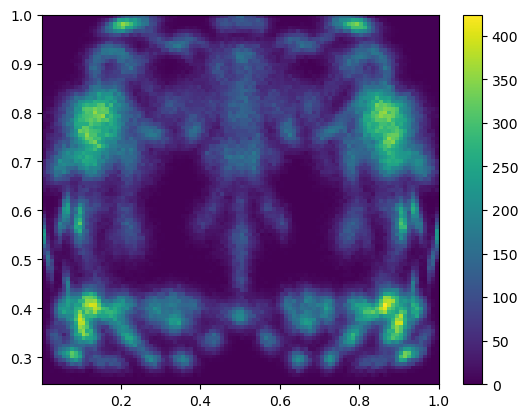

In [22]:
import matplotlib.pyplot as plt

plt.hist2d(all_x, all_y, bins=100)
plt.colorbar()
plt.show()

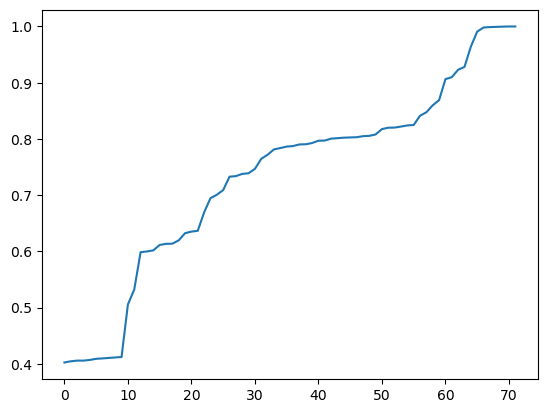

In [29]:
plt.plot(sorted(visibility_per_landmark))

In [23]:
widths = []
heights = []

for file in labels_dir.glob("*.txt"):

    xs = []
    ys = []

    with open(file) as f:

        for line in f:
            if not line.strip():
                continue

            x,y,v = line.split()

            xs.append(float(x))
            ys.append(float(y))

    widths.append(max(xs)-min(xs))
    heights.append(max(ys)-min(ys))

(array([  5.,  28.,  44., 136., 222., 246., 180., 108.,  30.,   3.]),
 array([0.631422 , 0.6425071, 0.6535922, 0.6646773, 0.6757624, 0.6868475,
        0.6979326, 0.7090177, 0.7201028, 0.7311879, 0.742273 ]),
 <BarContainer object of 10 artists>)

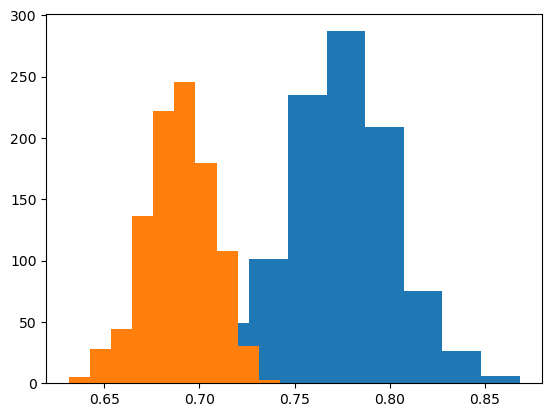

In [24]:
plt.hist(widths)
plt.hist(heights)

(array([  1.,  17.,  58., 169., 270., 270., 142.,  49.,  19.,   7.]),
 array([0.93537846, 0.97326741, 1.01115636, 1.04904531, 1.08693426,
        1.12482321, 1.16271216, 1.20060111, 1.23849006, 1.27637901,
        1.31426796]),
 <BarContainer object of 10 artists>)

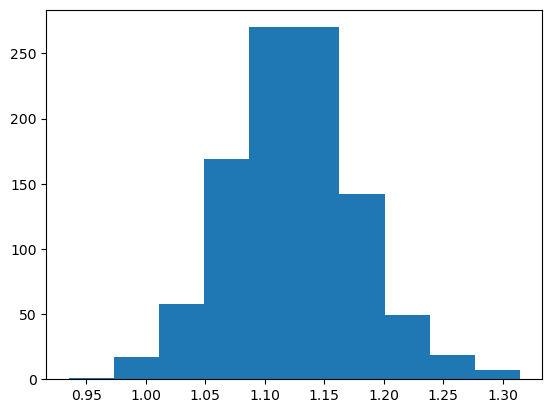

In [30]:
ratio = np.array(widths) / np.array(heights)
plt.hist(ratio)

In [32]:
from __future__ import annotations

from pathlib import Path
from typing import List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def load_shape_vector_from_label_file(
    label_file: str | Path,
) -> np.ndarray:
    """
    Load a landmark annotation file and convert it into a flattened shape vector.

    The expected label format is:
        x y v
        x y v
        ...
    with one face per file.

    Only x and y coordinates are used. Visibility is ignored for PCA.

    Args:
        label_file: Path to the label file.

    Returns:
        A NumPy array of shape (144,), corresponding to 72 landmarks with
        flattened x and y coordinates.

    Raises:
        ValueError: If the file contains zero or multiple face instances.
    """
    instances = parse_landmark_label_file(label_file)

    if len(instances) != 1:
        raise ValueError(
            f"Expected exactly one face instance in {label_file}, "
            f"but found {len(instances)}."
        )

    landmarks = instances[0]
    coords: List[float] = []

    for x_coord, y_coord, _ in landmarks:
        coords.extend([x_coord, y_coord])

    return np.asarray(coords, dtype=np.float32)

def build_pca_dataframe(
    dataset_root: str | Path,
    splits: Sequence[str] = ("train", "val", "test"),
) -> pd.DataFrame:
    """
    Build a DataFrame containing flattened landmark coordinates and metadata.

    Args:
        dataset_root: Root directory of the dataset.
        splits: Dataset splits to include.

    Returns:
        A DataFrame with metadata columns:
            - split
            - filename
            - rotation
        and 144 feature columns:
            - f_000 ... f_143
    """
    dataset_root = Path(dataset_root)
    rows = []

    for split_name in splits:
        labels_dir = dataset_root / split_name / "labels"

        for label_file in sorted(labels_dir.glob("*.txt")):
            shape_vector = load_shape_vector_from_label_file(label_file)
            rotation = extract_rotation_from_filename(label_file.name)

            row = {
                "split": split_name,
                "filename": label_file.stem,
                "rotation": rotation,
            }

            for index, value in enumerate(shape_vector):
                row[f"f_{index:03d}"] = float(value)

            rows.append(row)

    return pd.DataFrame(rows)

def run_shape_pca(
    df_shapes: pd.DataFrame,
    n_components: int = 10,
) -> Tuple[pd.DataFrame, PCA]:
    """
    Run PCA on flattened landmark coordinates.

    Args:
        df_shapes: DataFrame returned by build_pca_dataframe.
        n_components: Number of principal components.

    Returns:
        A tuple containing:
            - DataFrame with metadata and PCA projections
            - Fitted PCA object
    """
    feature_columns = [col for col in df_shapes.columns if col.startswith("f_")]
    x_matrix = df_shapes[feature_columns].to_numpy(dtype=np.float32)

    pca = PCA(n_components=n_components)
    transformed = pca.fit_transform(x_matrix)

    df_pca = df_shapes[["split", "filename", "rotation"]].copy()

    for index in range(n_components):
        df_pca[f"PC{index + 1}"] = transformed[:, index]

    return df_pca, pca


def plot_pca_scatter(
    df_pca: pd.DataFrame,
    x_component: str = "PC1",
    y_component: str = "PC2",
    color_by: str = "rotation",
    figsize: Tuple[int, int] = (8, 6),
) -> None:
    """
    Plot a 2D PCA scatter plot colored by a metadata column.

    Args:
        df_pca: DataFrame returned by run_shape_pca.
        x_component: Column name for x-axis.
        y_component: Column name for y-axis.
        color_by: Metadata column used for color grouping.
        figsize: Figure size.

    Returns:
        None
    """
    plt.figure(figsize=figsize)

    for group_value in sorted(df_pca[color_by].unique()):
        subset = df_pca[df_pca[color_by] == group_value]
        plt.scatter(
            subset[x_component],
            subset[y_component],
            label=group_value,
            alpha=0.65,
            s=18,
        )

    plt.xlabel(x_component)
    plt.ylabel(y_component)
    plt.title(f"{x_component} vs {y_component} colored by {color_by}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_explained_variance(
    pca: PCA,
    figsize: Tuple[int, int] = (8, 4),
) -> None:
    """
    Plot explained variance ratio and cumulative explained variance.

    Args:
        pca: Fitted PCA object.
        figsize: Figure size.

    Returns:
        None
    """
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    x_axis = np.arange(1, len(explained) + 1)

    plt.figure(figsize=figsize)
    plt.plot(x_axis, explained, marker="o", label="Explained variance ratio")
    plt.plot(x_axis, cumulative, marker="o", label="Cumulative explained variance")
    plt.xlabel("Principal component")
    plt.ylabel("Variance ratio")
    plt.title("PCA explained variance")
    plt.xticks(x_axis)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

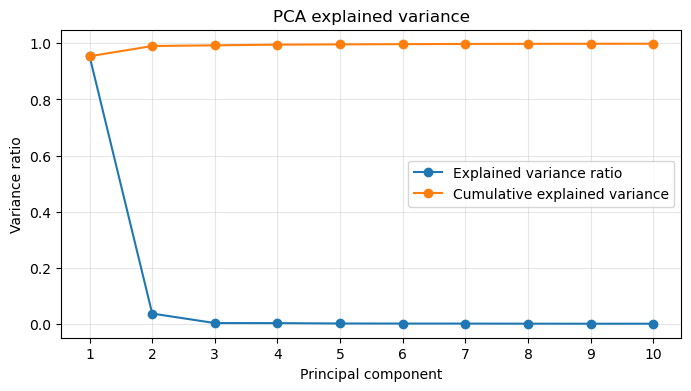

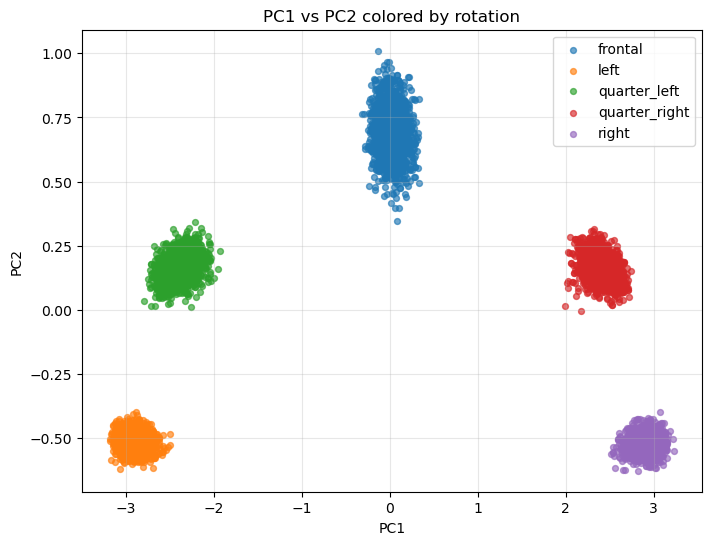

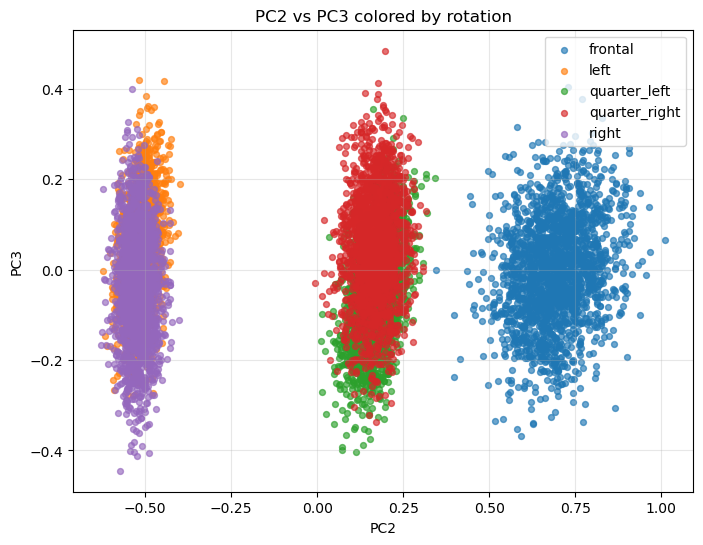

In [33]:
df_shapes = build_pca_dataframe("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")
df_pca, pca = run_shape_pca(df_shapes, n_components=10)

plot_explained_variance(pca)
plot_pca_scatter(df_pca, x_component="PC1", y_component="PC2", color_by="rotation")
plot_pca_scatter(df_pca, x_component="PC2", y_component="PC3", color_by="rotation")

In [54]:
from pathlib import Path
from typing import List, Tuple, Optional

import cv2
import numpy as np
import matplotlib.pyplot as plt


def plot_landmarks(
    image_path: str,
    keypoints_file: str,
    output_image_path: Optional[str] = None,
    show_names: bool = True,
    point_size: int = 40,
    font_size: int = 10,
):
    """
    Plot facial landmarks on an image using the new dataset format.

    Expected label format:
        x y v
        x y v
        ...

    where:
        x, y are normalized coordinates in [0,1]
        v = visibility (0 invisible, 1 visible)

    Args:
        image_path: Path to the image file.
        keypoints_file: Path to the landmark annotation file.
        output_image_path: Optional path to save the plotted image.
        show_names: If True, display landmark names. Otherwise display indices.
        point_size: Size of plotted landmark points.
        font_size: Size of landmark labels.
    """

    landmark_names = [
        'exR','enR','n','enL','exL','acR','aR','prn','aL','acL','sn',
        'chR','cphR','ls','cphL','chL','li','sl','pg','tR','oiR','tL','oiL',
        'faceO_23','faceO_24','faceO_25','faceO_26','faceO_27',
        'faceO_28','chin_29','faceO_30','faceO_31','faceO_32',
        'faceO_33','faceO_34','faceO_35','rightEB_36','rightEB_37',
        'rightEB_38','rightEB_39','rightEB_40','leftEB_41',
        'leftEB_42','leftEB_43','leftEB_44','leftEB_45','nose_46',
        'nose_47','rightE_48','rightE_49','rightE_50','rightE_51','leftE_52',
        'leftE_53','leftE_54','leftE_55','upperL_56','upperL_57','lowerL_58',
        'lowerL_59','lowerL_60','lowerL_61','lipE_62','upperL_63','upperL_64',
        'upperL_65','lipE_66','lowerL_67','lowerL_68','lowerL_69','chin_70','chin_71'
    ]

    # Load image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    # Read landmarks
    keypoints: List[Tuple[float, float, int]] = []

    with open(keypoints_file) as f:
        for line in f:
            if not line.strip():
                continue

            x, y, v = line.strip().split()
            keypoints.append((float(x), float(y), int(v)))

    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)

    for idx, (x, y, vis) in enumerate(keypoints):

        x_pixel = int(x * w)
        y_pixel = int(y * h)

        color = "red" if vis == 1 else "blue"

        plt.scatter(x_pixel, y_pixel, color=color, s=point_size)

        label = landmark_names[idx] if show_names else str(idx)

        offset = 1

        plt.text(
            x_pixel + offset,
            y_pixel - offset,
            label,
            fontsize=font_size,
            color="black",
            fontweight="bold",
        )

    title = "Landmarks with Names" if show_names else "Landmarks with Indices"

    plt.title(title)
    plt.axis("off")

    if output_image_path:
        plt.savefig(output_image_path, bbox_inches="tight")

    plt.show()

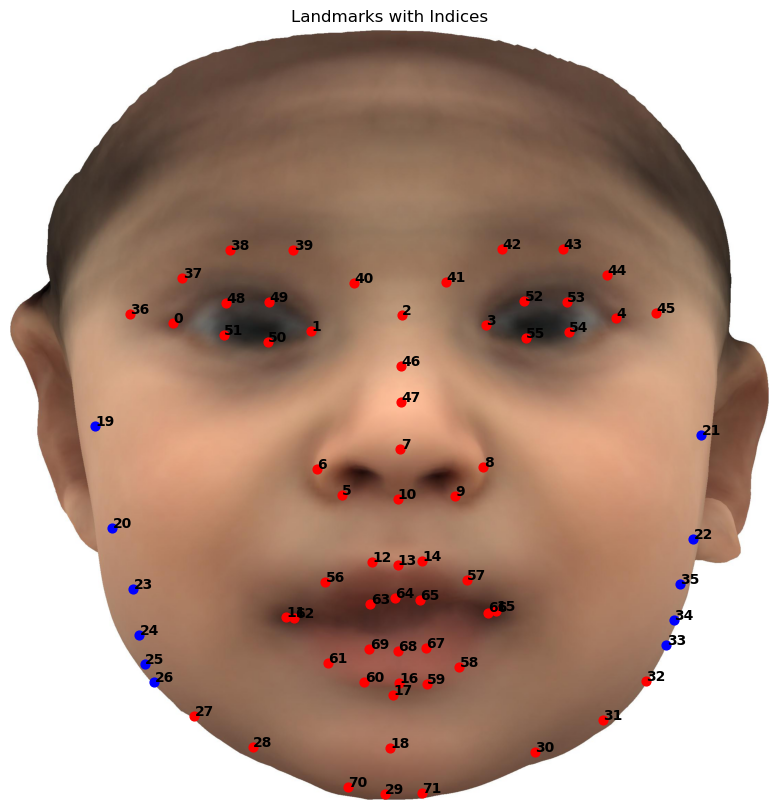

In [55]:
plot_landmarks("/Users/jocareher/Documents/synthetic_lmks_vis_dataset/train/images/synthetic_shape_00016_frontal.jpg", "/Users/jocareher/Documents/synthetic_lmks_vis_dataset/train/labels/synthetic_shape_00016_frontal.txt", show_names=False)

In [57]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


def run_pose_specific_pca(df_shapes, rotation, n_components=10):
    """
    Run PCA for a specific head pose.

    Args:
        df_shapes: DataFrame returned by build_pca_dataframe.
        rotation: Pose to analyze (frontal, left, right, quarter_left, quarter_right).
        n_components: Number of PCA components.

    Returns:
        fitted PCA object
    """

    df_pose = df_shapes[df_shapes["rotation"] == rotation]

    feature_cols = [c for c in df_pose.columns if c.startswith("f_")]

    X = df_pose[feature_cols].to_numpy()

    pca = PCA(n_components=n_components)
    pca.fit(X)

    return pca

def plot_pose_specific_variance(pca, title):

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    x = np.arange(1, len(explained) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(x, explained, marker='o', label="explained")
    plt.plot(x, cumulative, marker='o', label="cumulative")

    plt.xlabel("component")
    plt.ylabel("variance")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

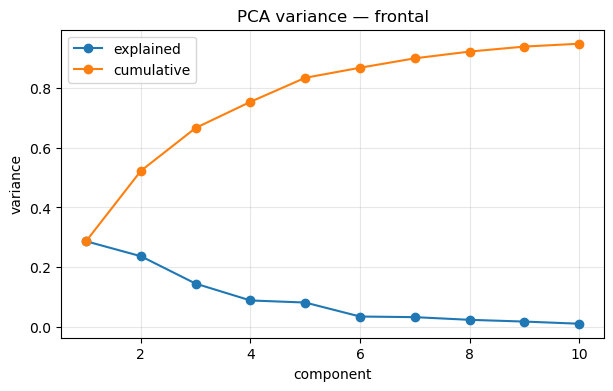

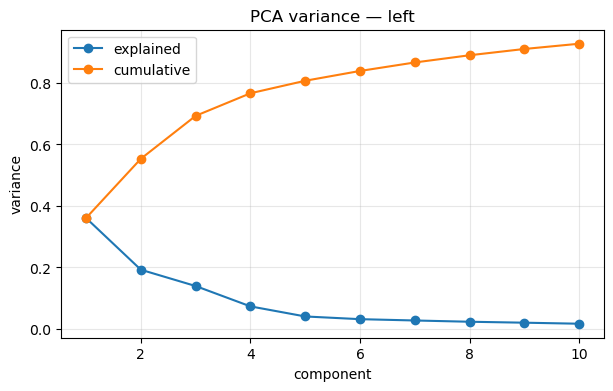

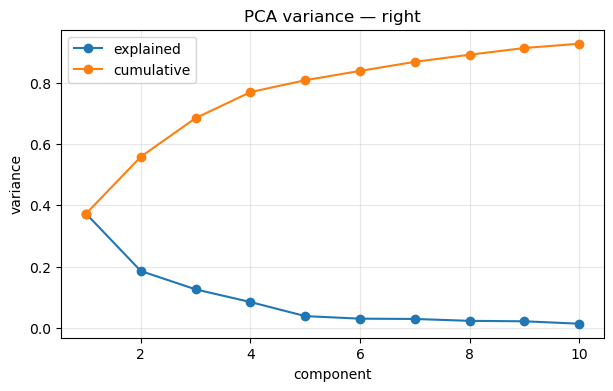

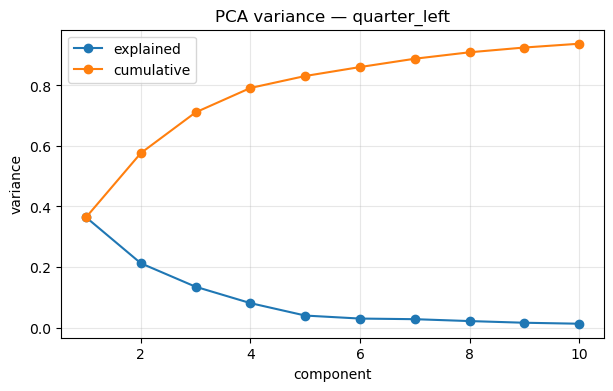

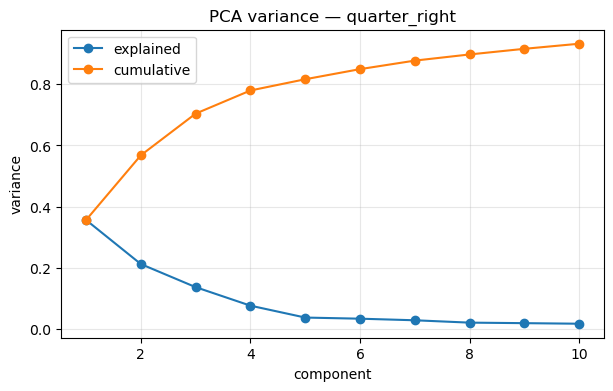

In [58]:
poses = ["frontal","left","right","quarter_left","quarter_right"]

for pose in poses:

    pca_pose = run_pose_specific_pca(df_shapes, pose)

    plot_pose_specific_variance(
        pca_pose,
        f"PCA variance — {pose}"
    )

In [59]:
def visualize_eigenshape(pca, component_index=0, scale=2.0):
    """
    Visualize landmark PCA modes.

    Args:
        pca: fitted PCA object
        component_index: component to visualize
        scale: deformation scale
    """

    mean_shape = pca.mean_.reshape(-1,2)
    eigenvec = pca.components_[component_index].reshape(-1,2)

    shape_plus  = mean_shape + scale * eigenvec
    shape_minus = mean_shape - scale * eigenvec

    plt.figure(figsize=(6,6))

    plt.scatter(mean_shape[:,0], mean_shape[:,1], c='black', label="mean")
    plt.scatter(shape_plus[:,0], shape_plus[:,1], c='red', label="+mode")
    plt.scatter(shape_minus[:,0], shape_minus[:,1], c='blue', label="-mode")

    plt.gca().invert_yaxis()

    plt.legend()
    plt.title(f"PCA mode {component_index+1}")

    plt.show()

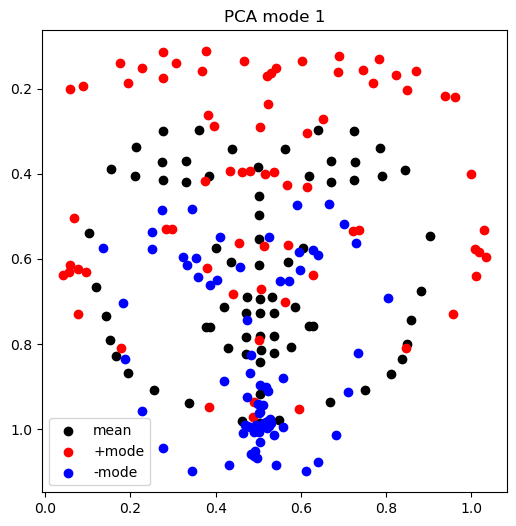

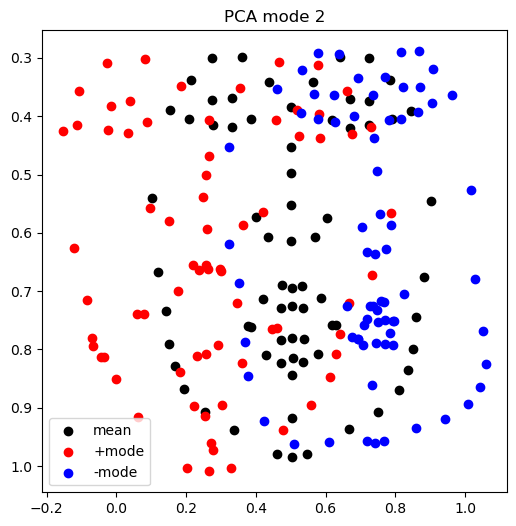

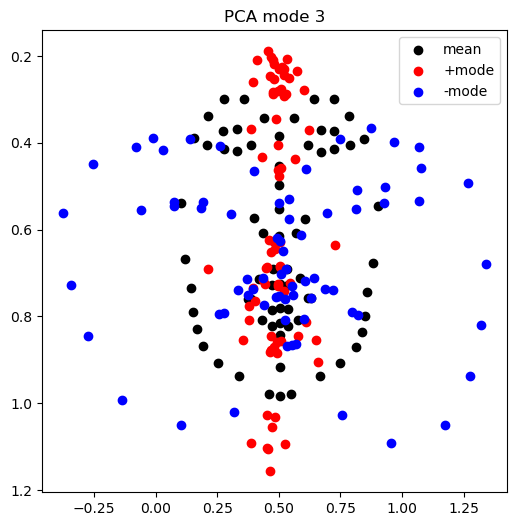

In [62]:
pca_frontal = run_pose_specific_pca(df_shapes,"frontal")

visualize_eigenshape(pca_frontal,0)
visualize_eigenshape(pca_frontal,1)
visualize_eigenshape(pca_frontal,2)